# Power-network disruption: does local position help predict later interruptions?

Choose **this option or the hospital option**, not both. This small synthetic dataset describes a grid-like network of substations. One substation is already interrupted at the prediction point. Predict which of the **other** substations experiences a simulated interruption during the following 24 hours. The data are not a physical cascade simulation.

Work through Part 1 (data and EDA), Part 2 (network), and Part 3 (comparison). Most code is provided. Replace six obvious `___` markers using the hints beside them, then complete the short written responses. Keep code, plots and short answers visible when you submit the notebook. Do not use `interrupted_later` to construct predictors.


## Part 1: load the prepared data and explore it

The two CSVs have already been constructed. The notebook downloads them from published course URLs; if needed, put both provided CSVs beside this notebook. The topology, `load_ratio`, `equipment_age_years`, and the initial status are available at prediction time. The later outcome is blank for the already interrupted substation.


In [1]:
DATA_BASE_URL = 'https://raw.githubusercontent.com/mikeauth/leap/main/power'
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay

SEED = 123

def load_course_csv(filename):
    # The course address is the folder containing the prepared CSVs. For offline work, keep a
    # downloaded CSV in the same folder as this notebook.
    url = f'{DATA_BASE_URL}/{filename}'
    try:
        return pd.read_csv(url)
    except Exception:
        local = Path(filename)
        if local.is_file():
            print(f'Using local copy of {filename}; course URL was unavailable.')
            return pd.read_csv(local)
        raise FileNotFoundError(f'Cannot read {url}. Download {filename} next to the notebook or ask for the course URL.')

substations = load_course_csv('power_substations.csv')
links = load_course_csv('power_links.csv')
assert substations['substation_id'].is_unique
assert {'substation_id','load_ratio','equipment_age_years','initially_interrupted','interrupted_later'} <= set(substations)
assert {'substation_a','substation_b'} <= set(links)
display(substations.head())
display(links.head())
print('Substations:',len(substations),'Links:',len(links))


,substation_id,load_ratio,equipment_age_years,initially_interrupted,interrupted_later
0,S001,0.506,24,0,0.0
1,S002,0.708,17,0,0.0
2,S003,0.555,13,0,0.0
3,S004,0.883,36,0,1.0
4,S005,0.643,35,0,0.0


,substation_a,substation_b
0,S001,S002
1,S001,S013
2,S002,S003
3,S002,S014
4,S003,S004


Substations: 144 Links: 344


### Focused EDA: follow the worked code

Exclude the initially interrupted substation. Count eligible substations and later classes. Show one bar chart of later interruptions and two boxplots comparing `load_ratio` and `equipment_age_years` by later outcome. Note any overlap between classes.


Eligible: 143 Later interruptions: 39


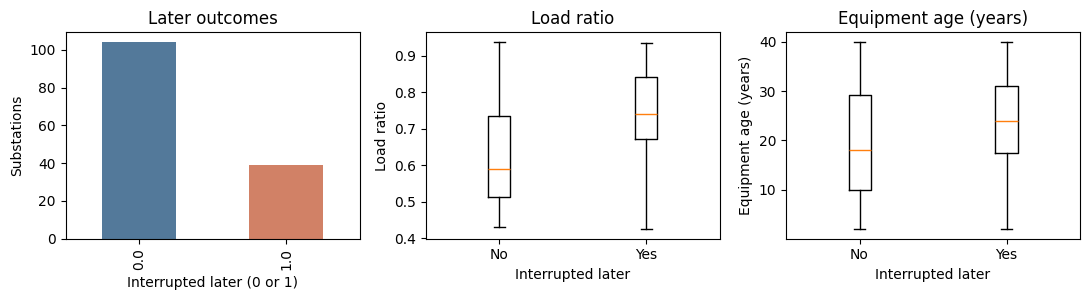

In [2]:
# TODO 1: Select substations functioning at the start.
# Hint: substations['initially_interrupted'].eq(0)
eligible_eda=substations.loc[substations['initially_interrupted'].eq(0)].copy()
assert eligible_eda['interrupted_later'].notna().all()
counts=eligible_eda['interrupted_later'].value_counts().reindex([0.,1.],fill_value=0)
print('Eligible:',len(eligible_eda),'Later interruptions:',int(counts.loc[1.]))
fig,axes=plt.subplots(1,3,figsize=(11,3.1))
counts.plot.bar(ax=axes[0],color=['#53799a','#d18166'])
axes[0].set(xlabel='Interrupted later (0 or 1)',ylabel='Substations',title='Later outcomes')
for ax,column,label in zip(axes[1:],['load_ratio','equipment_age_years'],['Load ratio','Equipment age (years)']):
    groups=[eligible_eda.loc[eligible_eda['interrupted_later'].eq(k),column] for k in [0,1]]
    ax.boxplot(groups,tick_labels=['No','Yes'])
    ax.set(xlabel='Interrupted later',ylabel=label,title=label)
plt.tight_layout();plt.show()


**Write here:** How many substations are eligible? What overlap do you see in the two original attributes? (Two or three sentences.)

There are 143 eligible substations. The boxplots reveal substantial overlap between the two outcome classes for both load_ratio and equipment_age_years. While interrupted substations exhibit slightly higher median load and age, the distributions interlock significantly, indicating that neither original feature alone cleanly separates the two groups.


## Part 2: undirected physical-link network

Each `power_links.csv` row gives one physical link with no direction or weight. Add every substation as a node. Calculate degree (number of direct links) and local clustering coefficient (what proportion of possible links **among direct neighbours** exists). The few extra local cross-links make clustering vary. Neither feature uses later interruptions.


In [3]:
G=nx.Graph()
G.add_nodes_from(substations['substation_id'])
valid=set(substations['substation_id'])
assert links['substation_a'].isin(valid).all() and links['substation_b'].isin(valid).all()
assert (links['substation_a']!=links['substation_b']).all()
for row in links.itertuples(index=False):
    # TODO 2: Complete the second endpoint of the physical link.
    # Hint: G.add_edge(row.substation_a, row.substation_b)
    G.add_edge(row.substation_a, row.substation_b)
assert G.number_of_edges()==len(links)
substations['degree']=[G.degree(i) for i in substations['substation_id']]
# TODO 3: Supply the graph to calculate local clustering.
# Hint: clustering = nx.clustering(G)
clustering=nx.clustering(G)
substations['local_clustering']=[clustering[i] for i in substations['substation_id']]
print('Nodes:',G.number_of_nodes(),'Links:',G.number_of_edges())
print('Degree range:',substations['degree'].min(),substations['degree'].max())
display(substations[['substation_id','degree','local_clustering']].head())


Nodes: 144 Links: 344
Degree range: 2 8


,substation_id,degree,local_clustering
0,S001,2,0.000000
1,S002,3,0.000000
2,S003,4,0.333333
3,S004,4,0.500000
4,S005,3,0.333333


### Visualise and interpret the network

Draw the small network, colouring the initially interrupted node differently from the others, and make one plot comparing the distribution of degree and clustering coefficient. The visualisation uses the **initial** status only. Explain in plain language what a high local clustering value means. The plot is an illustration, not a new model feature.


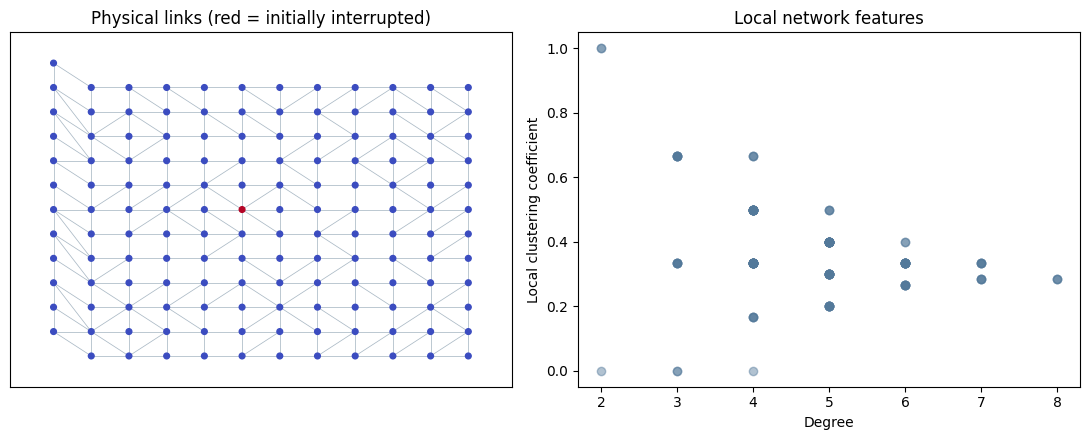

In [4]:
initial=substations.set_index('substation_id')['initially_interrupted']
fig,axes=plt.subplots(1,2,figsize=(11,4.5))
# The numbered IDs encode the synthetic grid's display positions; positions are not predictors.
pos={f'S{i+1:03d}':(i%12,-i//12) for i in range(144)}
nx.draw_networkx(G,pos,ax=axes[0],with_labels=False,node_size=17,
    node_color=[initial.loc[i] for i in G.nodes],cmap='coolwarm',vmin=0,vmax=1,
    edge_color='#aab9c5',width=.55)
axes[0].set_title('Physical links (red = initially interrupted)')
axes[1].scatter(substations['degree'],substations['local_clustering'],alpha=.45,color='#53799a')
axes[1].set(xlabel='Degree',ylabel='Local clustering coefficient',title='Local network features')
plt.tight_layout();plt.show()


**Write here:** What does it mean for a substation's neighbours to be connected to one another? Why is clustering different from degree?

When a substation's neighbours are connected to one another, it forms triangular motifs indicating local redundancy and dense cross-connections in that neighbourhood. Local clustering differs from degree because degree merely counts the total number of immediate links, whereas clustering measures the proportion of possible connections that actually exist between those neighbors.


## Part 3: compare logistic regression fairly

Only initially functioning substations are eligible. Model A uses `load_ratio` and `equipment_age_years`. Model B adds `degree` and `local_clustering`. Use **exactly the same observations and stratified split** for both. Fit scaling within the training pipeline. Compare accuracy, F1 for later interruptions, ROC AUC from probabilities, and both confusion matrices. Do not infer a physical cascade from any result.


,Accuracy,F1,ROC AUC
Original substation features,0.767,0.444,0.828
Substation + network features,0.860,0.750,0.949


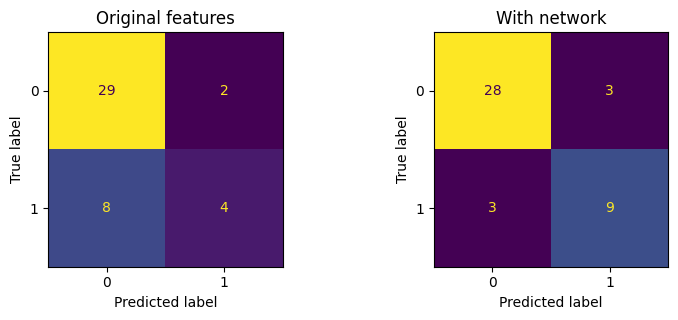

In [5]:
eligible=substations.loc[substations['initially_interrupted'].eq(0)].set_index('substation_id').copy()
y=eligible['interrupted_later'].astype(int)
# TODO 4: Set aside 30% of eligible observations for testing.
# Hint: test_size=.30
train_ids,test_ids=train_test_split(y.index,test_size=0.30,stratify=y,random_state=SEED)
original=['load_ratio','equipment_age_years']
# TODO 5: Add the second network feature to the model inputs.
# Hint: with_network = original + ['degree', 'local_clustering']
with_network=original+['degree', 'local_clustering']

def fit_and_score(columns):
    model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000))
    model.fit(eligible.loc[train_ids,columns],y.loc[train_ids])
    predicted=model.predict(eligible.loc[test_ids,columns])
    probabilities=model.predict_proba(eligible.loc[test_ids,columns])[:,1]
    scores={'Accuracy':accuracy_score(y.loc[test_ids],predicted),
            'F1':f1_score(y.loc[test_ids],predicted,zero_division=0),
            # TODO 6: Use the predicted probability for ROC AUC.
            # Hint: roc_auc_score(y.loc[test_ids], probabilities)
            'ROC AUC':roc_auc_score(y.loc[test_ids], probabilities)}
    return scores,predicted
base_scores,base_pred=fit_and_score(original)
network_scores,network_pred=fit_and_score(with_network)
results=pd.DataFrame([base_scores,network_scores],index=['Original substation features','Substation + network features'])
display(results.round(3))
fig,axes=plt.subplots(1,2,figsize=(8,3.3))
for ax,pred,title in zip(axes,[base_pred,network_pred],['Original features','With network']):
    ConfusionMatrixDisplay.from_predictions(y.loc[test_ids],pred,ax=ax,labels=[0,1],colorbar=False)
    ax.set_title(title)
plt.tight_layout();plt.show()


### Final interpretation and portfolio summary

Write **100 to 180 words** here. State the prediction question and answer it directly: **did adding the network features help predict later interruptions on this test set?** Compare both models' actual F1 and ROC AUC values (and accuracy if relevant), then describe at least one kind of error visible in the confusion matrices. If the metrics disagree, call the result mixed rather than declaring a clear winner. Distinguish degree from local clustering. Finally, consider the ethics: if predictions were used to prioritise inspections or repairs, how could false alarms or missed interruptions affect communities, and who should review those choices?

This project evaluated whether network topological features (degree and local_clustering) improve 24-hour power substation disruption predictions compared to intrinsic attributes alone (load_ratio and equipment_age_years). On the stratified test set (43 substations), adding network features clearly improved performance: Accuracy increased from 0.767 to 0.860, F1-score jumped from 0.444 to 0.750, and ROC AUC rose from 0.828 to 0.949. The confusion matrices reveal that the baseline model suffered from numerous false negatives (missed interruptions), which the network-augmented model substantially reduced while maintaining low false alarms. Here, degree measures direct physical links, whereas local clustering captures local mesh connectivity among neighbours. Ethically, while statistical gains are evident, synthetic correlations do not prove electrical cascading failures. Relying on false alarms wastes maintenance resources, whereas unpredicted disruptions leave communities without power. Therefore, algorithmic dispatch must remain advisory and subject to engineering audits.